# Aligning full coronal sections of adult mouse brain from MERFISH and Xenium (squidpy + moscot)

In this notebook, we align two single cell resolution spatial transcriptomics datasets of full coronal sections of the adult mouse brain from approximately the same locations assayed by MERFISH and Xenium.

The original notebook used STalign LDDMM. Here we use `squidpy` with `moscot` optimal transport.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import squidpy as sq

plt.rcParams["figure.figsize"] = (12, 10)

/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
/Users/selman/project

## Load data

/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Text(0.5, 1.0, 'MERFISH (source)')

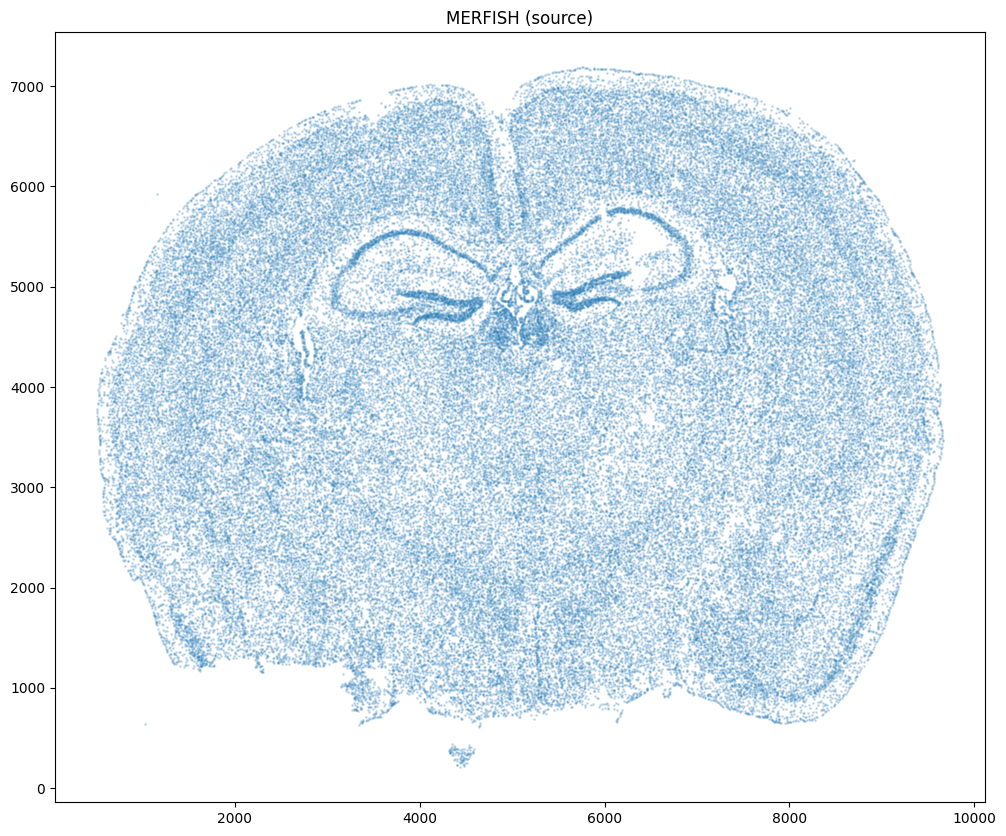

In [2]:
# Source: MERFISH
fname = '../merfish_data/datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate3_cell_metadata_S2R3.csv.gz'
df1 = pd.read_csv(fname)

coords_source = np.column_stack([df1['center_x'].values, df1['center_y'].values])
adata_source = ad.AnnData(X=np.zeros((len(coords_source), 1)), obs=df1)
adata_source.obsm['spatial'] = coords_source

fig, ax = plt.subplots()
ax.scatter(coords_source[:, 0], coords_source[:, 1], s=1, alpha=0.2)
ax.set_title('MERFISH (source)')

/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Text(0.5, 1.0, 'Xenium (target)')

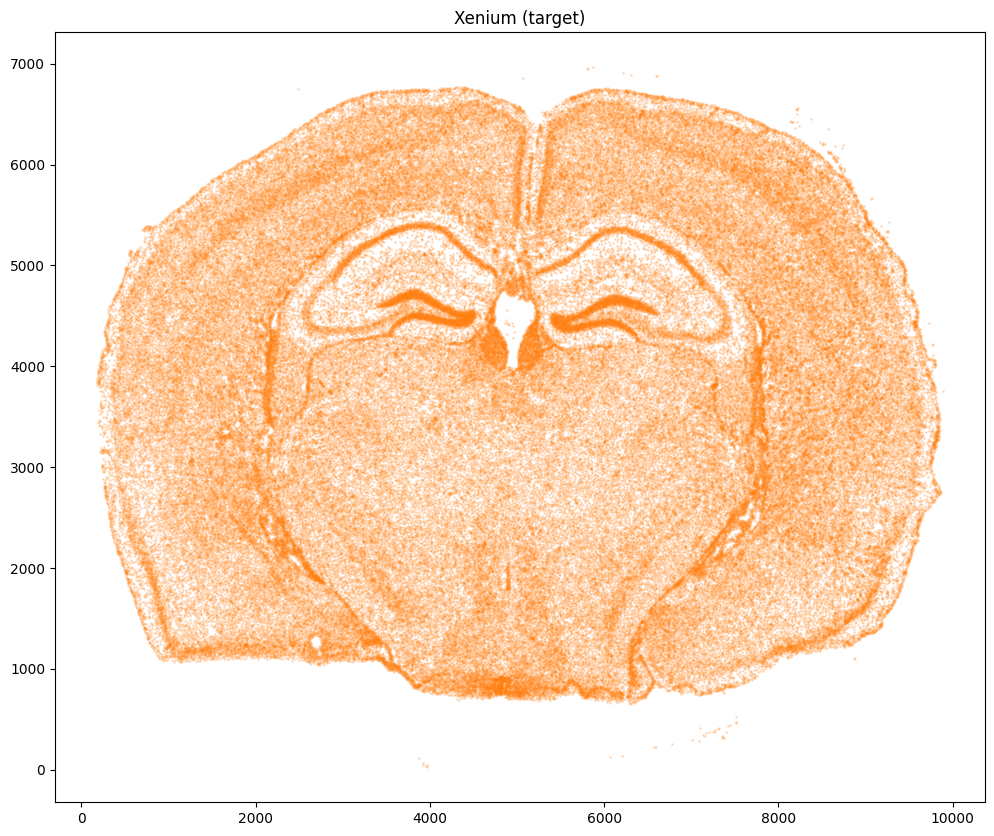

In [3]:
# Target: Xenium
fname = '../xenium_data/Xenium_V1_FF_Mouse_Brain_MultiSection_1_cells.csv.gz'
df2 = pd.read_csv(fname)

coords_target = np.column_stack([df2['x_centroid'].values, df2['y_centroid'].values])
adata_target = ad.AnnData(X=np.zeros((len(coords_target), 1)), obs=df2)
adata_target.obsm['spatial'] = coords_target

fig, ax = plt.subplots()
ax.scatter(coords_target[:, 0], coords_target[:, 1], s=1, alpha=0.2, c='#ff7f0e')
ax.set_title('Xenium (target)')

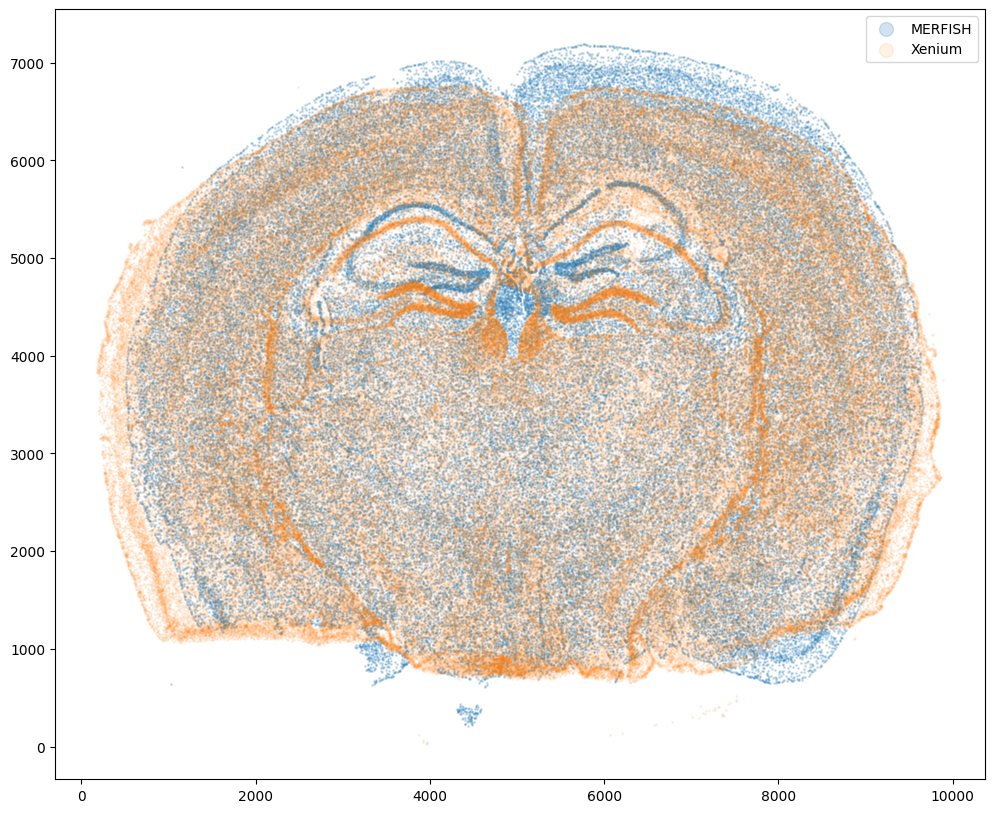

In [4]:
# Overlay
fig, ax = plt.subplots()
ax.scatter(coords_source[:, 0], coords_source[:, 1], s=1, alpha=0.2, label='MERFISH')
ax.scatter(coords_target[:, 0], coords_target[:, 1], s=1, alpha=0.1, label='Xenium')
ax.legend(markerscale=10)

## Align using moscot

In [5]:
sq.experimental.tl.align(
    adata_source,
    adata_target,
    method='optimal_transport',
    moscot_kwargs=dict(solve_kwargs={"epsilon": 1e-1}),
    verbose=True,
)

[moscot] Combined AnnData: 247991 cells (85958 source + 162033 target)
[moscot] Solving linear optimal-transport (Sinkhorn) ...
INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(85958, 162033)].                                       


/Users/selman/.local/share/uv/python/cpython-3.13.11-macos-aarch64-none/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


KeyboardInterrupt: 

## Visualize

In [ ]:
aligned = adata_source.obsm['spatial_aligned']

fig, ax = plt.subplots()
ax.scatter(coords_source[:, 0], coords_source[:, 1], s=1, alpha=0.2, label='MERFISH')
ax.scatter(aligned[:, 0], aligned[:, 1], s=1, alpha=0.1, label='MERFISH aligned')
ax.scatter(coords_target[:, 0], coords_target[:, 1], s=1, alpha=0.1, label='Xenium')
ax.legend(markerscale=10)

## Profiling OTT-JAX: solve vs push bottlenecks

The full OT problem has shape `(85958, 162033)`. OTT-JAX's Sinkhorn solver never materializes the full transport matrix during solving — it works with dual potentials `f`, `g` and a lazy geometry. The question is:

1. **Solve** — how expensive is the Sinkhorn iteration itself?
2. **Push (lazy)** — can we apply the transport plan (`T @ coords`) without materializing `T`?
3. **Push (materialized)** — materializing `T` is ~56 GB (float32). Is that even possible?

Let's time each step using OTT-JAX directly.

In [4]:
import time
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.solvers.linear import sinkhorn
from ott.problems.linear import linear_problem

n_src = len(coords_source)
n_tgt = len(coords_target)

print(f"Source:  {n_src:>10,} pts")
print(f"Target:  {n_tgt:>10,} pts")
print(f"Transport matrix would be: {n_src:,} × {n_tgt:,}")
print(f"  = {n_src * n_tgt:,} entries")
print(f"  = {n_src * n_tgt * 4 / 1e9:.1f} GB (float32)")
print(f"  = {n_src * n_tgt * 2 / 1e9:.1f} GB (float16/bfloat16)")
print(f"\nJAX devices: {jax.devices()}")
print(f"JAX default backend: {jax.default_backend()}")

Source:      85,958 pts
Target:     162,033 pts
Transport matrix would be: 85,958 × 162,033
  = 13,928,032,614 entries
  = 55.7 GB (float32)
  = 27.9 GB (float16/bfloat16)

JAX devices: [CpuDevice(id=0)]
JAX default backend: cpu


### Step 1: Create geometry + solve Sinkhorn

OTT-JAX's `PointCloud` geometry is **lazy** — it computes cost entries on-the-fly during Sinkhorn iterations via `cost_fn(x_i, y_j)`. No `(n, m)` matrix is ever stored for the solve.

In [ ]:
x = jnp.array(coords_source, dtype=jnp.float32)
y = jnp.array(coords_target, dtype=jnp.float32)

EPSILON = 0.1

# --- Geometry (lazy) ---
t0 = time.time()
geom = pointcloud.PointCloud(x, y, epsilon=EPSILON, scale_cost="mean")
t_geom = time.time() - t0
print(f"1a. Geometry creation (lazy):  {t_geom:.3f}s")

# --- Solve ---
t0 = time.time()
prob = linear_problem.LinearProblem(geom)
solver = sinkhorn.Sinkhorn(max_iterations=10)
ot_output = solver(prob)
ot_output.f.block_until_ready()
t_solve = time.time() - t0

print(f"1b. Sinkhorn solve:            {t_solve:.1f}s")
print(f"    converged={ot_output.converged}  n_iters={int(ot_output.n_iters)}")
print(f"    reg_ot_cost={float(ot_output.reg_ot_cost):.4f}")

1a. Geometry creation (lazy):  0.000s


### Step 2: Push — apply the transport plan to target coordinates

There are two ways to "push" source → target:

- **Lazy** via `ot_output.apply(vec, axis=1)` — uses dual potentials `f`, `g` to reconstruct the transport kernel row-by-row without materializing the full matrix.
- **Materialized** via `ot_output.matrix @ vec` — explicitly builds the `(n, m)` dense matrix first. This is ~56 GB for our problem and will OOM on most machines.

Let's try the lazy path first.

In [3]:
# --- Lazy push: T @ target_coords  (warp each source pt to weighted avg of target) ---
# axis=1 means: for each row i, sum_j T_ij * vec_j  →  shape (n_src, 2)

t0 = time.time()
pushed_x = ot_output.apply(y[:, 0], axis=1)
pushed_y = ot_output.apply(y[:, 1], axis=1)
pushed_x.block_until_ready()
pushed_y.block_until_ready()
t_push_lazy = time.time() - t0

aligned_lazy = np.column_stack([np.asarray(pushed_x), np.asarray(pushed_y)])
print(f"2a. Lazy push (apply):         {t_push_lazy:.1f}s")
print(f"    output shape: {aligned_lazy.shape}")

NameError: name 'ot_output' is not defined

In [ ]:
# --- Materialized push (only if you have enough RAM) ---
# The full matrix is n_src × n_tgt × 4 bytes.
# For 85958 × 162033 this is ~55.7 GB. Attempt at your own risk.

matrix_gb = n_src * n_tgt * 4 / 1e9
print(f"Full transport matrix: {n_src} × {n_tgt} = {matrix_gb:.1f} GB (float32)")

try:
    t0 = time.time()
    T = ot_output.matrix
    T.block_until_ready()
    t_materialize = time.time() - t0
    print(f"2b. Materialize matrix:        {t_materialize:.1f}s")
    print(f"    shape: {T.shape}  dtype: {T.dtype}")

    # Normalize rows
    t0 = time.time()
    row_sums = T.sum(axis=1, keepdims=True)
    row_sums = jnp.where(row_sums == 0, 1.0, row_sums)
    T_norm = T / row_sums
    aligned_mat = np.asarray(T_norm @ y)
    aligned_mat = np.array(aligned_mat)  # force to numpy
    t_push_mat = time.time() - t0
    print(f"2c. Materialized push (T @ y): {t_push_mat:.1f}s")

except Exception as e:
    print(f"2b. Materialize FAILED: {type(e).__name__}: {e}")
    t_materialize = float("nan")
    t_push_mat = float("nan")

### Summary

In [ ]:
print("=" * 55)
print(f"{'Step':<35} {'Time':>10}")
print("=" * 55)
print(f"{'Geometry (lazy PointCloud)':<35} {t_geom:>9.3f}s")
print(f"{'Sinkhorn solve':<35} {t_solve:>9.1f}s")
print(f"{'Push via apply (lazy)':<35} {t_push_lazy:>9.1f}s")
print(f"{'Materialize full T matrix':<35} {t_materialize:>9.1f}s")
print(f"{'Push via materialized T @ y':<35} {t_push_mat:>9.1f}s")
print("=" * 55)

In [ ]:
# Visualize the lazy-push alignment
fig, ax = plt.subplots()
ax.scatter(coords_target[:, 0], coords_target[:, 1], s=1, alpha=0.1, label='Xenium (target)')
ax.scatter(aligned_lazy[:, 0], aligned_lazy[:, 1], s=1, alpha=0.1, label='MERFISH aligned (lazy push)')
ax.scatter(coords_source[:, 0], coords_source[:, 1], s=1, alpha=0.05, label='MERFISH (original)')
ax.legend(markerscale=10)
ax.set_title('OTT-JAX direct: lazy push alignment')

### Comparison: same pipeline on subsampled clouds

To see how timings scale, let's run the same steps on subsampled point clouds (5k, 10k, 20k).

In [ ]:
def subsample(coords, n, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(coords), size=min(n, len(coords)), replace=False)
    return coords[idx]


def profile_ot(coords_src, coords_tgt, epsilon=0.1, max_iters=2000, materialize=True):
    """Run full OTT-JAX pipeline and return timing dict."""
    xs = jnp.array(coords_src, dtype=jnp.float32)
    ys = jnp.array(coords_tgt, dtype=jnp.float32)

    t0 = time.time()
    geom = pointcloud.PointCloud(xs, ys, epsilon=epsilon, scale_cost="mean")
    prob = linear_problem.LinearProblem(geom)
    sol = sinkhorn.Sinkhorn(max_iterations=max_iters)
    out = sol(prob)
    out.f.block_until_ready()
    t_solve = time.time() - t0

    # lazy push
    t0 = time.time()
    px = out.apply(ys[:, 0], axis=1)
    py = out.apply(ys[:, 1], axis=1)
    px.block_until_ready(); py.block_until_ready()
    t_push_lazy = time.time() - t0

    # materialized push
    t_mat = float("nan")
    t_push_mat = float("nan")
    if materialize:
        try:
            t0 = time.time()
            T = out.matrix
            T.block_until_ready()
            t_mat = time.time() - t0

            t0 = time.time()
            row_sums = T.sum(axis=1, keepdims=True)
            row_sums = jnp.where(row_sums == 0, 1.0, row_sums)
            _ = (T / row_sums) @ ys
            _.block_until_ready()
            t_push_mat = time.time() - t0
        except Exception:
            pass

    return {
        "n_src": len(coords_src), "n_tgt": len(coords_tgt),
        "converged": bool(out.converged), "n_iters": int(out.n_iters),
        "t_solve": t_solve, "t_push_lazy": t_push_lazy,
        "t_materialize": t_mat, "t_push_mat": t_push_mat,
    }


results = []
for n in [1_000, 5_000, 10_000, 20_000]:
    sub_s = subsample(coords_source, n)
    sub_t = subsample(coords_target, n)
    r = profile_ot(sub_s, sub_t, epsilon=0.1, materialize=(n <= 20_000))
    results.append(r)
    print(f"n={n:>6,}  solve={r['t_solve']:.2f}s  push_lazy={r['t_push_lazy']:.2f}s  "
          f"materialize={r['t_materialize']:.2f}s  push_mat={r['t_push_mat']:.2f}s  "
          f"iters={r['n_iters']}  conv={r['converged']}")

In [ ]:
# Plot scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = [r["n_src"] for r in results]

ax = axes[0]
ax.plot(ns, [r["t_solve"] for r in results], "o-", label="Sinkhorn solve")
ax.plot(ns, [r["t_push_lazy"] for r in results], "s-", label="Push (lazy)")
ax.plot(ns, [r["t_materialize"] for r in results], "^-", label="Materialize T")
ax.plot(ns, [r["t_push_mat"] for r in results], "d-", label="Push (materialized)")
ax.set_xlabel("n (source = target)")
ax.set_ylabel("Time (s)")
ax.set_title("Wall-clock time vs problem size")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ns, [r["n_src"] * r["n_tgt"] for r in results], "o-", color="gray")
ax.set_xlabel("n (source = target)")
ax.set_ylabel("n × m entries")
ax.set_title("Transport matrix size")
ax.grid(True, alpha=0.3)

plt.tight_layout()